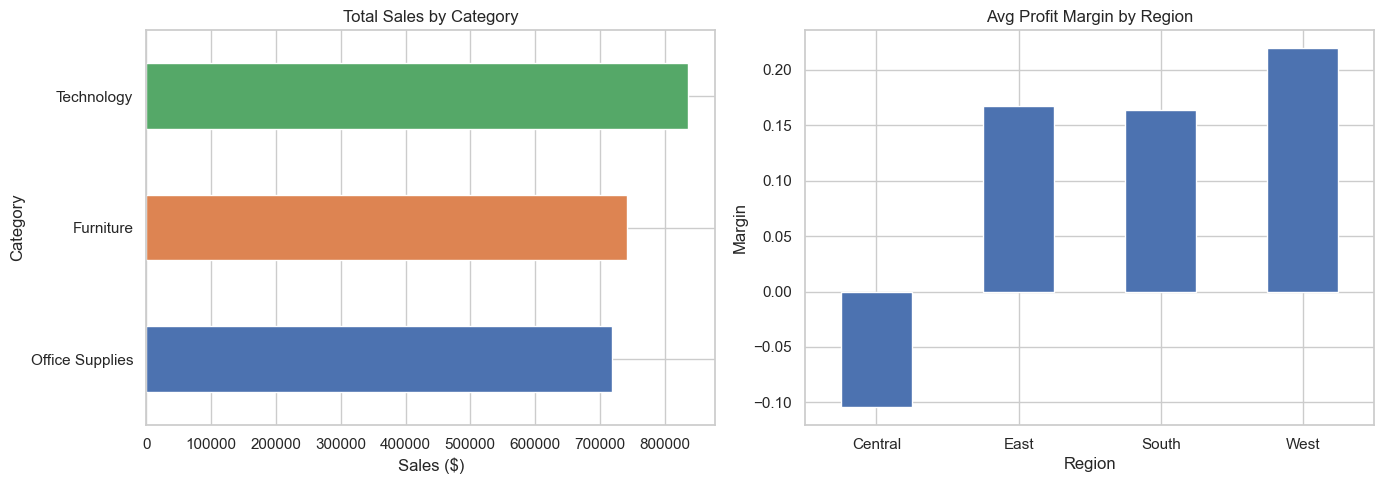

In [1]:
# Cell 1 — Sales by Category
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_data.csv")
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by category
cat_sales = df.groupby("Category")["Sales"].sum().sort_values()
cat_sales.plot(kind="barh", ax=axes[0], color=["#4C72B0","#DD8452","#55A868"])
axes[0].set_title("Total Sales by Category")
axes[0].set_xlabel("Sales ($)")

# Profit margin by region
df.groupby("Region")["Profit Margin"].mean().plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].set_title("Avg Profit Margin by Region")
axes[1].set_ylabel("Margin")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("../data/processed/eda_overview.png", dpi=150)
plt.show()

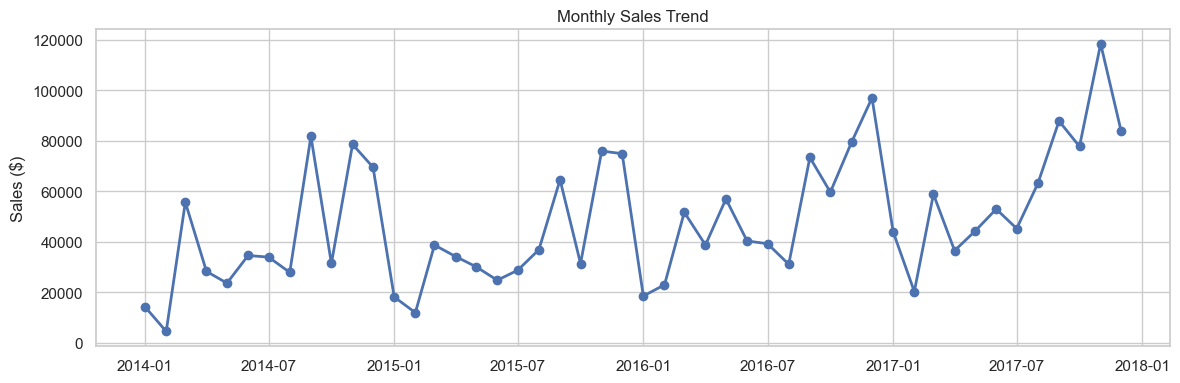

In [2]:
# Cell 2 — Monthly Sales Trend
monthly = df.groupby(["Order Year","Order Month"])["Sales"].sum().reset_index()
monthly["Period"] = pd.to_datetime(monthly[["Order Year","Order Month"]].rename(
    columns={"Order Year":"year","Order Month":"month"}).assign(day=1))

plt.figure(figsize=(12, 4))
plt.plot(monthly["Period"], monthly["Sales"], marker="o", linewidth=2)
plt.title("Monthly Sales Trend")
plt.ylabel("Sales ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

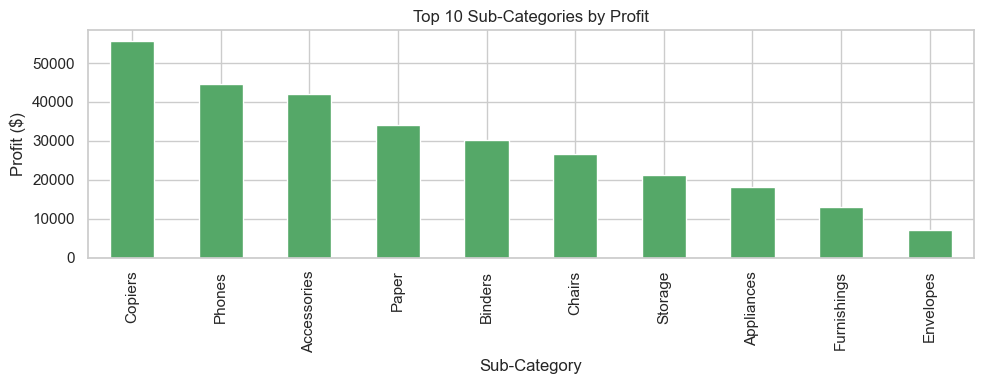

In [3]:
# Cell 3 — Top 10 Sub-Categories by Profit
top_sub = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).head(10)
top_sub.plot(kind="bar", figsize=(10,4), color="#55A868")
plt.title("Top 10 Sub-Categories by Profit")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()